In [14]:
print("HELLO WORLD")

HELLO WORLD


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import trajectory

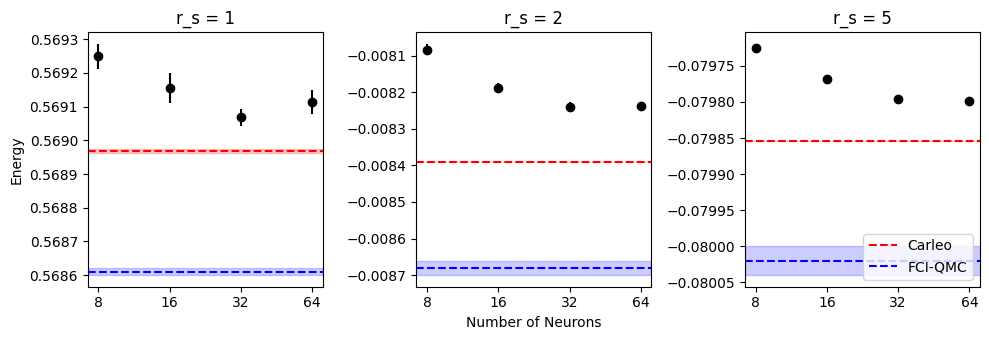

In [16]:
path = "width/one{}/rs{}_best/{}"

numNeurons = [8,16,32,64]
r_ws_list = [1,2,5]

CY_vals = {
    "1" : 0.5780,
    "2" : -0.00181,
    "5" : -0.0764,
}

carleo_vals = {
    "1" : (0.568967,6e-6),
    "2" : (-0.008391,1e-6),
    "5" : (-0.0798544,4e-7),
}

fci_vals = {
    "1" : (0.56861,1e-5),
    "2" : (-0.00868,2e-5),
    "5" : (-0.08002,2e-5),
}

fig, axs = plt.subplots(figsize=(10,3.5), nrows=1, ncols=3)

for (i,r_ws) in enumerate(r_ws_list):
    for numNeuron in numNeurons:
        (mean,error) = trajectory.getStatistics(path.format(
           numNeuron, r_ws, "statistics.txt"
        ))
        axs[i].errorbar(numNeuron, mean, yerr=error, fmt='o', color='black')

    (carleo_mean,carleo_err) = carleo_vals[str(r_ws)]
    (fci_mean,fci_err) = fci_vals[str(r_ws)]

    axs[i].set_title("r_s = {}".format(r_ws))
    axs[i].axhline(y=carleo_mean, color='red', linestyle='--', label='Carleo')
    axs[i].axhspan(carleo_mean - carleo_err, carleo_mean + carleo_err, alpha=0.2, color='red')
    axs[i].axhline(y=fci_mean, color='blue', linestyle='--', label='FCI-QMC')
    axs[i].axhspan(fci_mean - fci_err, fci_mean + fci_err, alpha=0.2, color='blue')
    axs[i].set_xscale('log', base=2)
    axs[i].set_xticks([8, 16, 32, 64])
    axs[i].set_xticklabels(["8", "16", "32", "64"])

axs[1].set_xlabel("Number of Neurons") 
axs[0].set_ylabel("Energy")
axs[-1].legend(loc='lower right')

plt.tight_layout()
plt.show()

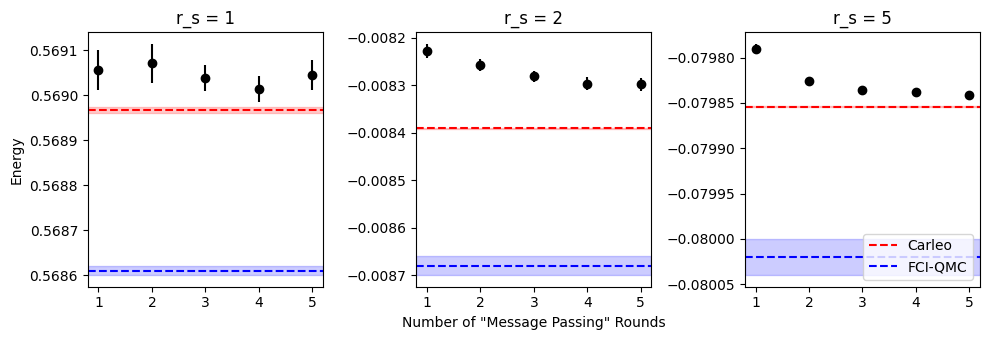

In [17]:
path = "depth/{}/rs{}_best/{}"

r_ws_list = [1,2,5]

filepaths = [
    "layers1",
    "layers2-relaunch",
    "layers3-relaunch",
    "layers4-relaunch",
    "layers5-relaunch",
]

carleo_vals = {
    "1" : (0.568967,6e-6),
    "2" : (-0.008391,1e-6),
    "5" : (-0.0798544,4e-7),
}

fci_vals = {
    "1" : (0.56861,1e-5),
    "2" : (-0.00868,2e-5),
    "5" : (-0.08002,2e-5),
}

fig, axs = plt.subplots(figsize=(10,3.5), nrows=1, ncols=3)

for (i,r_ws) in enumerate(r_ws_list):
    
    for (j,filepath) in enumerate(filepaths):
        (mean,error) = trajectory.getStatistics(path.format(
           filepath, r_ws, "statistics.txt"
        ))
        axs[i].errorbar(j+1, mean, yerr=error, fmt='o', color='black')

    (carleo_mean,carleo_err) = carleo_vals[str(r_ws)]
    (fci_mean,fci_err) = fci_vals[str(r_ws)]

    axs[i].set_title("r_s = {}".format(r_ws))
    axs[i].axhline(y=carleo_mean, color='red', linestyle='--', label='Carleo')
    axs[i].axhspan(carleo_mean - carleo_err, carleo_mean + carleo_err, alpha=0.2, color='red')
    axs[i].axhline(y=fci_mean, color='blue', linestyle='--', label='FCI-QMC')
    axs[i].axhspan(fci_mean - fci_err, fci_mean + fci_err, alpha=0.2, color='blue')
    axs[i].set_xticks([i+1 for i in range(len(filepaths))])
    axs[i].set_xticklabels([str(i+1) for i in range(len(filepaths))])

axs[1].set_xlabel("Number of \"Message Passing\" Rounds") 
axs[0].set_ylabel("Energy")
axs[-1].legend(loc='lower right')

plt.tight_layout()
plt.show()